In [3]:
#%pip install pandas pyreadstat

Note: you may need to restart the kernel to use updated packages.


In [1]:
import scipy
import os
import numpy as np
import matplotlib.pyplot as plt


In [2]:

# Define the file path
# Example file path: r'C:/Users/Desktop/file.sav'
file_path4MK = '/projects/sabr7402/K_Cor/Data/DEM_no94.sav' #_avgd.sav
file_path3MK = '/projects/sabr7402/K_Cor/Data/suvi_dem_3MK.sav'

loaded_data_4MK = scipy.io.readsav(file_path4MK, idict=None, python_dict=False, uncompressed_file_name=None, verbose=True)
loaded_data_3MK = scipy.io.readsav(file_path3MK, idict=None, python_dict=False, uncompressed_file_name=None, verbose=True)

#print(loaded_data.keys())
#plt.imshow(loaded_data['dem_cube'][6].data)

--------------------------------------------------
Date: Fri Mar 13 11:01:14 2026
User: sbruce
Host: EclipseBook.local
--------------------------------------------------
Format: 12
Architecture: x86_64
Operating System: darwin
IDL Version: 8.9.0
--------------------------------------------------
Successfully read 4 records of which:
 - 1 are of type TIMESTAMP
 - 1 are of type VARIABLE
 - 1 are of type VERSION
--------------------------------------------------
Available variables:
 - dem_cube [<class 'numpy.ndarray'>]
--------------------------------------------------
--------------------------------------------------
Date: Fri Mar 13 11:14:30 2026
User: sbruce
Host: EclipseBook.local
--------------------------------------------------
Format: 12
Architecture: x86_64
Operating System: darwin
IDL Version: 8.9.0
--------------------------------------------------
Successfully read 4 records of which:
 - 1 are of type TIMESTAMP
 - 1 are of type VARIABLE
 - 1 are of type VERSION
-------------

In [3]:
#temperature_array = np.arange(5.5, 7.21, 0.1)
#temperature_array = np.arange(5.5, 6.61, 0.1)
temperature_array_3MK = np.arange(5.5, 6.451, 0.1) #for 3MK
temperature_array_4MK = np.arange(5.5, 6.61, 0.1) #for 4MK
#print(temperature_array)
#print(len(temperature_array))

In [4]:
cutoff_MK_3MK = 5

cutoff_K_3MK = cutoff_MK_3MK * 1e6

temperature_linear_3MK = 10 ** np.array(temperature_array_3MK)  #in K

total_fordiv_3MK = np.zeros((1280, 1280))
final_weighted_3MK = np.zeros((1280, 1280))

for temp in range(len(temperature_array_3MK[:])):
    t_lin_3MK = temperature_linear_3MK[temp]         # linear K
    data_3MK = loaded_data_3MK['dem_cube'][temp].data         # DEM at this temp

    # if temp is above cutoff, skip its contribution
    if t_lin_3MK > cutoff_K_3MK:
        continue

    total_fordiv_3MK += data_3MK
    final_weighted_3MK += data_3MK * t_lin_3MK

mask_valid_3MK = total_fordiv_3MK > 0
final_map_3MK = np.full_like(final_weighted_3MK, np.nan, dtype=float)
final_map_3MK[mask_valid_3MK] = final_weighted_3MK[mask_valid_3MK] / total_fordiv_3MK[mask_valid_3MK]  # in K

final_map_MK_3MK= final_map_3MK / 1e6


In [5]:
cutoff_MK_4MK = 5

cutoff_K_4MK = cutoff_MK_4MK * 1e6

temperature_linear_4MK = 10 ** np.array(temperature_array_4MK)  #in K

total_fordiv_4MK = np.zeros((1280, 1280))
final_weighted_4MK = np.zeros((1280, 1280))

for temp in range(len(temperature_array_4MK[:])):
    t_lin_4MK = temperature_linear_4MK[temp]         # linear K
    data_4MK = loaded_data_4MK['dem_cube'][temp].data         # DEM at this temp

    # if temp is above cutoff, skip its contribution
    if t_lin_4MK > cutoff_K_4MK:
        continue

    total_fordiv_4MK += data_4MK
    final_weighted_4MK += data_4MK * t_lin_4MK

mask_valid_4MK = total_fordiv_4MK > 0
final_map_4MK = np.full_like(final_weighted_4MK, np.nan, dtype=float)
final_map_4MK[mask_valid_4MK] = final_weighted_4MK[mask_valid_4MK] / total_fordiv_4MK[mask_valid_4MK]  # in K

final_map_MK_4MK= final_map_4MK / 1e6


Text(0.5, 1.0, 'SUVI DEM Temperatures (3MK Cutoff)')

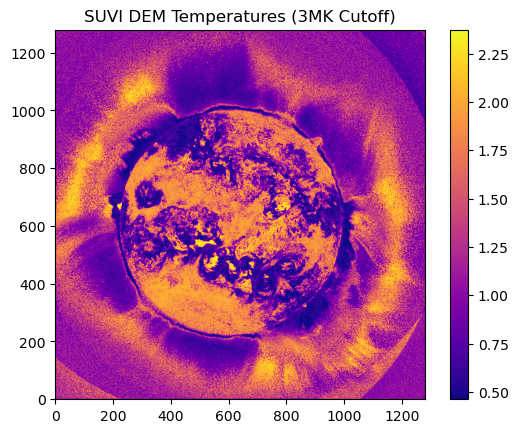

In [6]:
plt.imshow(final_map_MK_3MK, vmin=np.percentile(final_map_MK_3MK, 5), vmax=np.percentile(final_map_MK_3MK, 99), origin='lower', cmap = 'plasma')
plt.colorbar()
plt.title("SUVI DEM Temperatures (3MK Cutoff)")
#plt.savefig('suvi_dem_IDL_3MKcutoff.png', dpi = 800)
#average images
#try 0.5 -  2MK range
#make 4MK and plot that shows runaway high temps

Text(0.5, 1.0, 'SUVI DEM Temperatures (4MK Cutoff)')

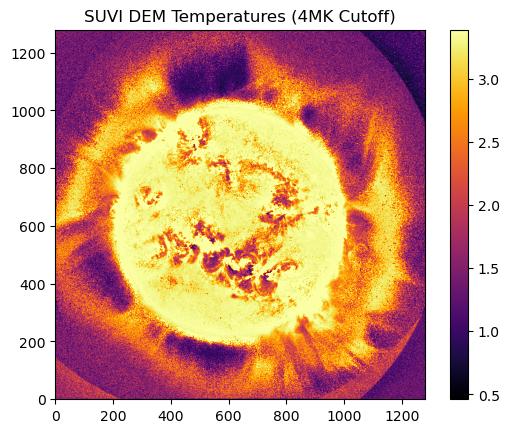

In [7]:
plt.imshow(final_map_MK_4MK, vmin=np.percentile(final_map_MK_4MK, 1), vmax=np.percentile(final_map_MK_4MK, 90), origin='lower', cmap = 'inferno') #vmax=np.percentile(final_map_MK_4MK, 90)
plt.colorbar()
plt.title("SUVI DEM Temperatures (4MK Cutoff)")
#plt.savefig('suvi_dem_IDL_4MKcutoff.png', dpi = 800)
#average images
#try 0.5 -  2MK range
#make 4MK and plot that shows runaway high temps

In [9]:
import pickle
with open("suvi_3MK.pkl", "wb") as file:
    pickle.dump(final_map_MK_3MK, file)
with open("suvi_4MK.pkl", "wb") as file:
    pickle.dump(final_map_MK_4MK, file)

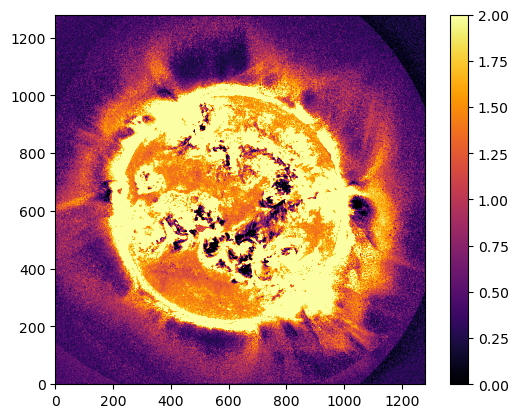

In [33]:
diffplot = final_map_MK_4MK - final_map_MK_3MK
plt.imshow(diffplot, origin = 'lower', vmin = 0, vmax = 2, cmap = 'inferno') #vmin=0,vmax=2
plt.colorbar()

In [11]:
# Source - https://stackoverflow.com/a/44874588
# Posted by alkasm, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-30, License - CC BY-SA 4.0

def circ_mask(h, w, center=(610,610), radius=410):

    if center is None: # use the middle of the image
        center = (int(w/2), int(h/2))
    if radius is None: # use the smallest distance between the center and image walls
        radius = min(center[0], center[1], w-center[0], h-center[1])

    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask


In [12]:
mask = circ_mask(1280, 1280)

# --- Apply mask (set inside circle to NaN) ---
masked_img = final_map_MK_4MK.astype(float)   # convert so NaN is allowed
masked_img[mask] = np.nan

# --- Optional: visualize (NaN will appear black) ---
#display_img = np.nan_to_num(masked_img, nan=0).astype(np.uint8)

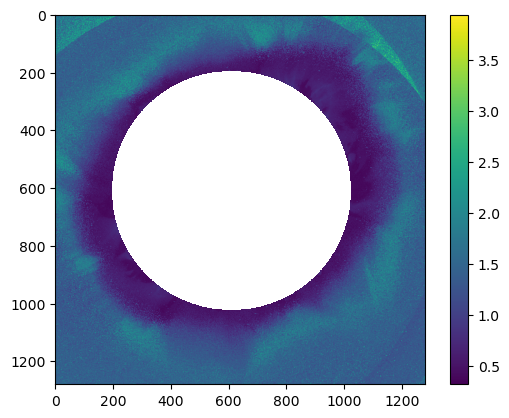

In [13]:
plt.imshow(masked_img)
plt.colorbar()

(10, 1280, 1280)
10


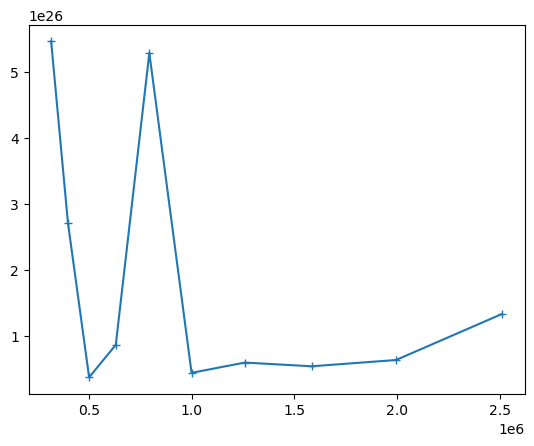

In [30]:
dem_cube_shape = (loaded_data['dem_cube'][:].data ).shape
dem_loaded = np.zeros([dem_cube_shape[0],dem_cube_shape[1],dem_cube_shape[2]])
for demidx in range(0,dem_cube_shape[0]):
    dem_loaded[demidx,:,:] =  (loaded_data['dem_cube'][demidx].data )
print((dem_loaded).shape)
plt.plot(temperature_linear,dem_loaded[:,600,600],'-+')
print(len(temperature_linear))
plt.show()

In [26]:
print(final_map_MK_5mk[600][600])
#truncate values to 0 before DEM in SUVI
#coadd an hour's worth of data , start w 15min
#disp print pointing offst for eah channel

0.7902921725968062


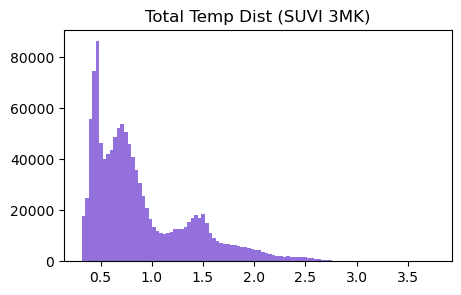

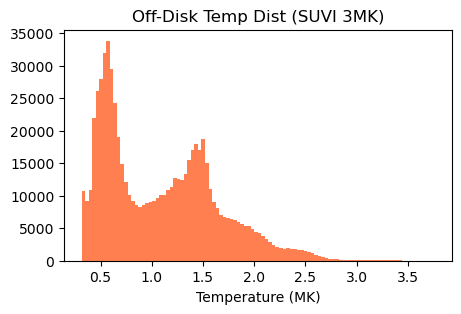

In [17]:
#plt.hist(np.ravel(final_map_MK_5mk[1000:1200,100:1200]),bins=100)
import pickle 

plt.figure(figsize=(5, 3))
plt.title("Total Temp Dist (SUVI 3MK)")
plt.hist(np.ravel(final_map_MK_4MK[100:1200,100:1200]),bins=100, color = 'mediumpurple')
pk = '/projects/sabr7402/K_Cor/Data/average_SUVI_LONG.pkl'
with open(pk, 'wb') as file:
    pickle.dump((final_map_MK_4MK), file)

plt.show()
plt.figure(figsize=(5, 3))

plt.hist(np.ravel(masked_img[100:1200,100:1200]),bins=100, color = 'coral')

pk2 = '/projects/sabr7402/K_Cor/Data/average_SUVI_LONG_masked.pkl'
with open(pk2, 'wb') as file:
    pickle.dump((masked_img), file)

plt.title("Off-Disk Temp Dist (SUVI 3MK)")
plt.xlabel("Temperature (MK)")
#plt.savefig('suvi_temp_dist_3MK.png')
#plt.yscale('log')
plt.show()
#projects/sabr7402/K_Cor/Data/SUVI_data/GOES_16/LONG/OR_SUVI-L1b-Fe093_G16_s20231100320126_e20231100320126_c20231100320322.fits.gz


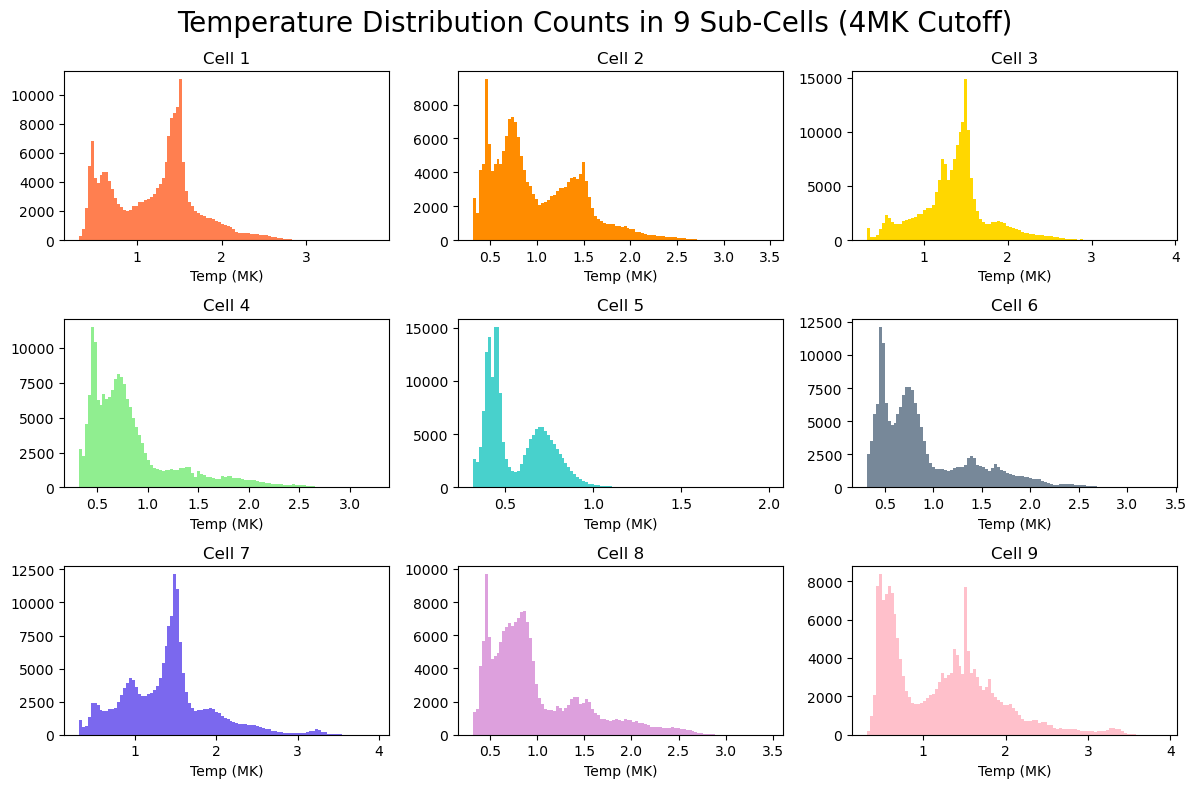

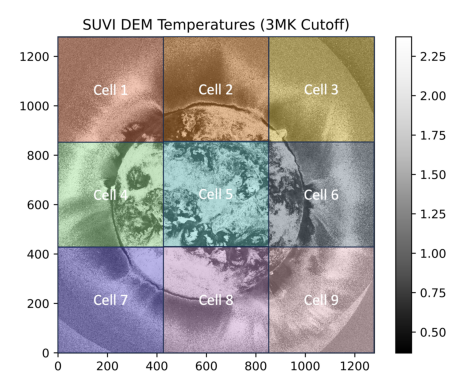

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.ravel()  # flatten so we can index easily

fig.suptitle("Temperature Distribution Counts in 9 Sub-Cells (4MK Cutoff)", fontsize = 20)

regions = [

    (slice(850,1275), slice(0,425)),     # Cell 1: upper left
    (slice(850,1275), slice(425,850)),   # Cell 2: upper middle
    (slice(850,1275), slice(850,1275)),  # Cell 3: upper right

    (slice(425,850), slice(0,425)),      # Cell 4: middle left
    (slice(425,850), slice(425,850)),    # Cell 5: center
    (slice(425,850), slice(850,1275)),   # Cell 6: middle right

    (slice(0,425), slice(0,425)),        # Cell 7: lower left
    (slice(0,425), slice(425,850)),      # Cell 8: lower middle
    (slice(0,425), slice(850,1275)),     # Cell 9: lower right
]

colors = ['coral', 'darkorange', 'gold', 'lightgreen', 'mediumturquoise', 
          'lightslategray', 'mediumslateblue', 'plum', 'pink']

    
for i, (ys, xs) in enumerate(regions):
    data = final_map_MK_4MK[ys, xs]
    axes[i].hist(np.ravel(data), bins=100, color = colors[i])
    axes[i].set_title(f"Cell {i+1}")
    axes[i].set_xlabel("Temp (MK)")

plt.tight_layout()
#fig.savefig("Temp_Dist_Cells_3MK.png")
plt.show()

plt.figure()

import matplotlib.image as mpimg
img = mpimg.imread('SUVI_temp_cells.png')
plt.axis('off')
plt.imshow(img)

#plot log scaled histograms of original suvi channel images. 

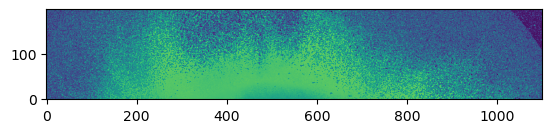

In [90]:
plt.imshow(final_map_MK_5mk[1000:1200,100:1200], origin='lower')
#calculate differences between temps in 3mk and 4mk
#redo plots for aia to compare on-disk temperatures